# Predicting Real Estate Prices Using Linear Regression Models

## About

This notebook presents an end-to-end Real Estate Prices Prediction model using Python, Linear Regression and Machine Learning.

It covers Exploratory Data Analysis (EDA), feature adjustments and improvements, model training, and evaluation using different regression models.

## Data Tidying

In [1]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("files/real_estate_prices.csv", header=0)

print(f"The model contains {df.shape[0]} training examples and {df.shape[1] - 1} features.\n")

df.head()

The model contains 506 training examples and 18 features.



,price,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,airport,n_hos_beds,n_hot_rooms,waterbody,rainfall,bus_ter,parks
0,24.0,0.00632,32.31,0.538,6.575,65.2,4.35,3.81,4.18,4.01,24.7,4.98,YES,5.480,11.1920,River,23,YES,0.049347
1,21.6,0.02731,37.07,0.469,6.421,78.9,4.99,4.70,5.12,5.06,22.2,9.14,NO,7.332,12.1728,Lake,42,YES,0.046146
2,34.7,0.02729,37.07,0.469,7.185,61.1,5.03,4.86,5.01,4.97,22.2,4.03,NO,7.394,101.1200,NaN,38,YES,0.045764
3,33.4,0.03237,32.18,0.458,6.998,45.8,6.21,5.93,6.16,5.96,21.3,2.94,YES,9.268,11.2672,Lake,45,YES,0.047151
4,36.2,0.06905,32.18,0.458,7.147,54.2,6.16,5.86,6.37,5.86,21.3,5.33,NO,8.824,11.2896,Lake,55,YES,0.039474


### Data Dictionary

| Feature | Description |
| :--- | ---: |
| price | Value of the house |
| crime_rate | Crime rate in that neighborhood |
| resid_area | Proportion of residential area in the town |
| air_qual | Quality of air in that neighborhood |
| room_num | Average number of rooms in houses of that locality |
| age | How old is the house construction in years |
| dist1 | Distance from employment hub 1 |
| dist2 | Distance from employment hub 2 |
| dist3 | Distance from employment hub 3 |
| dist4 | Distance from employment hub 4 |
| teachers | Number of teachers per thousand population in the town |
| poor_prop | Proportion of poor population in the town |
| airport | Is there an airport in the city? (Yes/No) |
| n_hos_beds  | Number of hospital beds per 1000 population in the town |
| n_hot_rooms  | Number of hotel rooms per 1000 population in the town |
| waterbody | What type of natural fresh water source is there in the city (lake/ river/ both/ none) |
| rainfall | The yearly average rainfall in centimeters |
| bus_ter | Is there a bus terminal in the city? (Yes/No) |
| parks | Proportion of land assigned as parks and green areas in the town |

## Pre-Processing

In this step we will adjust the data so it can be used in the models and will also improve some of the data so the model can make better predictions.

### Feature Adjustements

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price        506 non-null    float64
 1   crime_rate   506 non-null    float64
 2   resid_area   506 non-null    float64
 3   air_qual     506 non-null    float64
 4   room_num     506 non-null    float64
 5   age          506 non-null    float64
 6   dist1        506 non-null    float64
 7   dist2        506 non-null    float64
 8   dist3        506 non-null    float64
 9   dist4        506 non-null    float64
 10  teachers     506 non-null    float64
 11  poor_prop    506 non-null    float64
 12  airport      506 non-null    object 
 13  n_hos_beds   498 non-null    float64
 14  n_hot_rooms  506 non-null    float64
 15  waterbody    351 non-null    object 
 16  rainfall     506 non-null    int64  
 17  bus_ter      506 non-null    object 
 18  parks        506 non-null    float64
dtypes: float

#### Observations:
1. _airport_, _waterbody_, and _bus_ter_ are objects. They need to be updated to numbers so the model can run.
2. _n_hos_beds_ and _waterbody_ have missing values.
3. _bus_ter_ might only have YES as value (based on what's shown above after the df.head() in the Data Dictionary).

In [4]:
#Deleting the bus_ter column in case all values on that column are YES
bus_ter_no_count = (df['bus_ter'] != 'YES').sum()
print(f"Amount of values inside bus_ter that are different than YES: {bus_ter_no_count}")
if bus_ter_no_count == 0:
    print("Deleting the \"bus_ter\" column.\n")
    del df["bus_ter"]

#Updating the objects to numbers (which ends up removing the missing values from waterbody)
df = pd.get_dummies(df).astype(float)

#Adding the mean values to n_hos_beds since only 8 examples don't have value for that column
df.n_hos_beds = df.n_hos_beds.fillna(df.n_hos_beds.mean())

df.info()

Amount of values inside bus_ter that are different than YES: 0
Deleting the "bus_ter" column.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     506 non-null    float64
 1   crime_rate                506 non-null    float64
 2   resid_area                506 non-null    float64
 3   air_qual                  506 non-null    float64
 4   room_num                  506 non-null    float64
 5   age                       506 non-null    float64
 6   dist1                     506 non-null    float64
 7   dist2                     506 non-null    float64
 8   dist3                     506 non-null    float64
 9   dist4                     506 non-null    float64
 10  teachers                  506 non-null    float64
 11  poor_prop                 506 non-null    float64
 12  n_hos_beds               

### Feature Improvements

In [5]:
df.describe(percentiles=[.01, .25, .5, .75, .99])

,price,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,...,poor_prop,n_hos_beds,n_hot_rooms,rainfall,parks,airport_NO,airport_YES,waterbody_Lake,waterbody_Lake and River,waterbody_River
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,...,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,22.528854,3.613524,41.136779,0.554695,6.284634,68.574901,3.971996,3.628775,3.960672,3.618972,...,12.653063,7.899767,13.041605,39.181818,0.054454,0.448617,0.551383,0.191700,0.140316,0.361660
std,9.182176,8.601545,6.860353,0.115878,0.702617,28.148861,2.108532,2.108580,2.119797,2.099203,...,7.141062,1.464939,5.238957,12.513697,0.010632,0.497845,0.497845,0.394028,0.347659,0.480957
min,5.000000,0.006320,30.460000,0.385000,3.561000,2.900000,1.130000,0.920000,1.150000,0.730000,...,1.730000,5.268000,10.057600,3.000000,0.033292,0.000000,0.000000,0.000000,0.000000,0.000000
1%,7.010000,0.013610,31.253500,0.398000,4.524450,6.610000,1.460000,1.040000,1.371000,0.991000,...,2.883000,5.400300,10.088080,20.000000,0.036648,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.025000,0.082045,35.190000,0.449000,5.885500,45.025000,2.270000,1.940000,2.232500,1.940000,...,6.950000,6.659000,11.189800,28.000000,0.046464,0.000000,0.000000,0.000000,0.000000,0.000000
50%,21.200000,0.256510,39.690000,0.538000,6.208500,77.500000,3.385000,3.010000,3.375000,3.070000,...,11.360000,7.963000,12.720000,39.000000,0.053507,0.000000,1.000000,0.000000,0.000000,0.000000
75%,25.000000,3.677083,48.100000,0.624000,6.623500,94.075000,5.367500,4.992500,5.407500,4.985000,...,16.955000,9.076000,14.170800,50.000000,0.061397,1.000000,1.000000,0.000000,0.000000,1.000000
99%,50.000000,41.370330,55.650000,0.871000,8.335000,100.000000,9.437500,9.109000,9.477500,9.155500,...,33.918500,10.620100,15.399520,60.000000,0.082915,1.000000,1.000000,1.000000,1.000000,1.000000
max,50.000000,88.976200,57.740000,0.871000,8.780000,100.000000,12.320000,11.930000,12.320000,11.940000,...,37.970000,10.876000,101.120000,60.000000,0.086711,1.000000,1.000000,1.000000,1.000000,1.000000


#### Observations:
1. Possible skewness or outliers in _crime_rate_, _n_hot_rooms_ and _rainfall_.
2. The columns _dist1_ to _dist4_ show the distance between 4 different employment hubs and can be merged into 1, with the average of the distances.

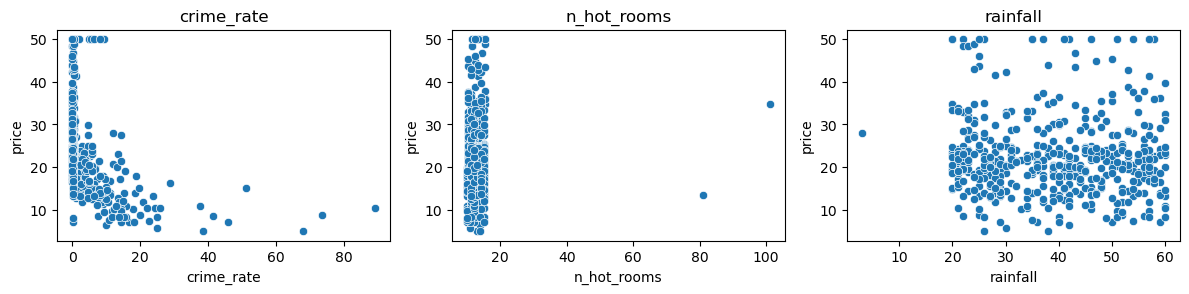

In [6]:
#Creating a function to plot the possible outliers
def plot_outliers():
    features = ["crime_rate", "n_hot_rooms", "rainfall"]

    plt.figure(figsize=(12,8))
    for i, col in enumerate(features):
        plt.subplot(3, 3, i+1)
        sns.scatterplot(x=df[col], y=df['price'])
        plt.title(col)
    plt.tight_layout()
    plt.show()

plot_outliers()

#### Fixing Crime Rate

The relationship on _crime_rate_ looks like a log relationship and we want to transform it into a linear relationship.
To do that, we transform the _crime_rate_ data into the log of itself.
Since logs are undefined for value zero, we add the constant 0.1 when making the trasnformation.

In [7]:
df.crime_rate = np.log(0.1+df.crime_rate)

#### Fixing n_hot_rooms
All the _n_hot_rooms_ that are greater than 2 times the 99th percentile are updated to be 2 times the 99th percentile.

In [8]:
upper_value = np.percentile(df.n_hot_rooms,[99])[0]
df.loc[(df.n_hot_rooms > 2 * upper_value), "n_hot_rooms"] = 2 * upper_value

#### Fixing rainfall
All the _rainfall_ values that are smaller than 30% of the lower value are updated to exactly 30% of hte lower value.

In [9]:
lower_value = np.percentile(df.rainfall, [1])[0]
df.loc[(df.rainfall < 0.3 * lower_value), "rainfall"] = 0.3 * lower_value

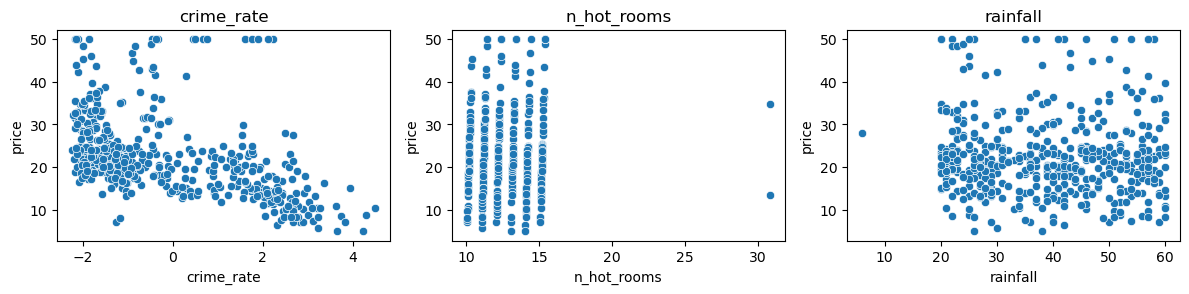

In [10]:
plot_outliers()

#### Creating an _avg_dist_ column

An _avg_dist_ column is created to contain the average distance to the employment hubs and will be used instead of the 4 original variables.

In [11]:
df["avg_dist"] = (df.dist1 + df.dist2 + df.dist3 + df.dist4) / 4

del df["dist1"]
del df["dist2"]
del df["dist3"]
del df["dist4"]

#### Correlation Analysis

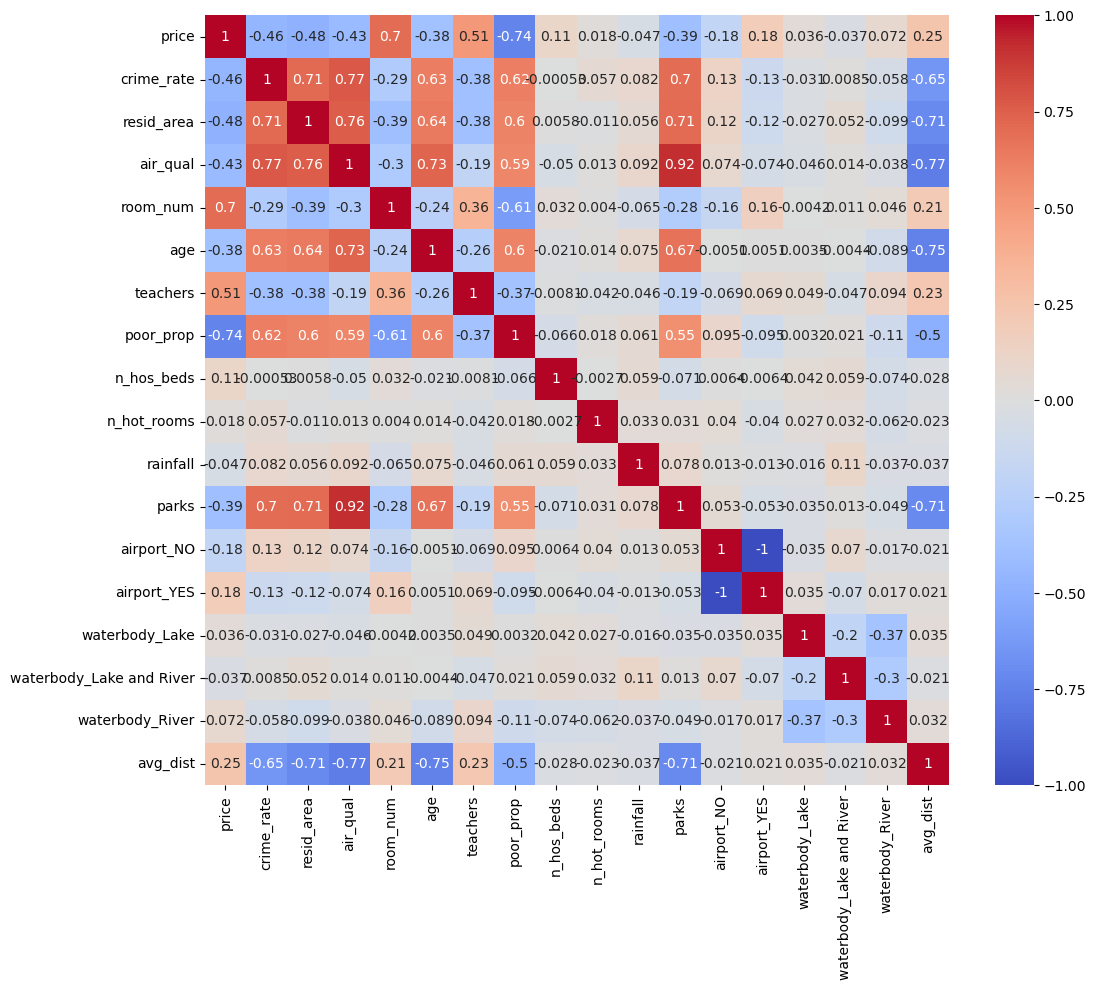

In [12]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

#### Observations:
1. _parks_ and _air_quality_ have high correlation between them.

#### Correlation between _parks_ and _air_quality_
Due to the high correlation between _parks_ and _air_quality_, we can remove the one with lower correlation with price (y), which in this case is _parks_

In [13]:
del df["parks"]

## Train-Test Split

Splitting the data set into a set to train the data and another set to test how accurate the model is.
The Train set contains 80% of the total data, while the Test set contains the remaining 20%.

In [14]:
#Splitting the data into Train and Test data
random_state = 0
X = df.drop("price", axis = 1)
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = random_state)

#Scaling the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Amount of examples on the Train set: {X_train.shape[0]}")
print(f"Amount of examples on the Test set: {X_test.shape[0]}")

Amount of examples on the Train set: 404
Amount of examples on the Test set: 102


## Model Building and Prediction

This section creates 5 different Regression models and runs them against the Train set and the Test set.

In [15]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=0.5),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state = random_state),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state = random_state)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_train_hat = model.predict(X_train)
    y_test_hat = model.predict(X_test)
    
    y_train_hat_score = r2_score(y_train, y_train_hat)
    y_test_hat_score = r2_score(y_test, y_test_hat)

    print(f"{name}:")
    print(f"\tModel Prediction Score against the training set: {y_train_hat_score:.2%}")
    print(f"\tModel Prediction Score against the test set: {y_test_hat_score:.2%}")

Linear Regression:
	Model Prediction Score against the training set: 75.60%
	Model Prediction Score against the test set: 55.64%
Ridge Regression:
	Model Prediction Score against the training set: 75.60%
	Model Prediction Score against the test set: 55.62%
Lasso Regression:
	Model Prediction Score against the training set: 75.40%
	Model Prediction Score against the test set: 55.24%
Random Forest:
	Model Prediction Score against the training set: 98.15%
	Model Prediction Score against the test set: 77.43%
Gradient Boosting:
	Model Prediction Score against the training set: 98.29%
	Model Prediction Score against the test set: 77.84%


## Model Accuracy

Based on the predictions above, the __Gradient Boosting__ model has the best performance when compared to the other 4 models used.

It had a score of __98.29%__ against the Train data, and __77.84%__ against the Test data.

Below we can see a plot containing the Actual Price vs the Predicted Price for the __Gradient Boosting__ model, and also the 5 features that were most important to the model.

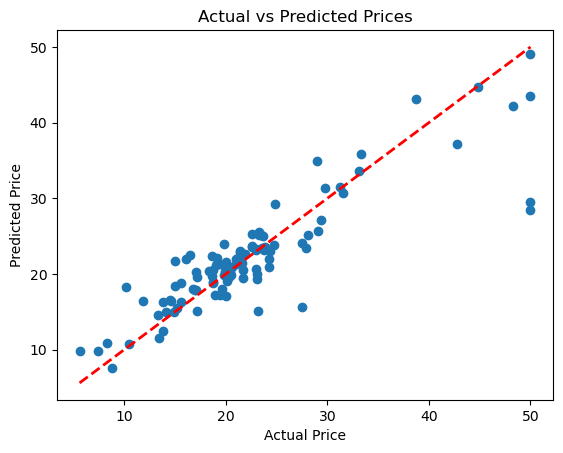

In [16]:
model = models['Gradient Boosting']
model.fit(X_train, y_train)
y_test_hat = model.predict(X_test)

plt.scatter(y_test, y_test_hat)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

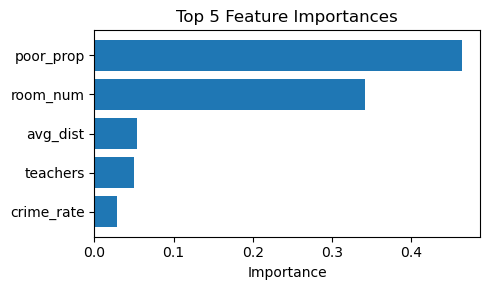

In [17]:
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': models['Gradient Boosting'].feature_importances_
}).sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(5, 3))
plt.barh(feature_importance_df.head(5)['Feature'], 
         feature_importance_df.head(5)['Importance'])
plt.xlabel('Importance')
plt.title('Top 5 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()